# N6 — kNN Financial Peer Lists (M1)

Builds M1 peer lists via cosine kNN in the 64-dimensional normalised financial ratio space.
For each focal firm-year, finds the k most similar firms within the same fyear cross-section.

**Input:** `financials_normalized.parquet` (N2) + `selected_features.json` (N2)
**Output:** `peers_m1.parquet` — schema: `focal_tic | focal_fyear | peer_tic | rank | similarity_score | model`


In [1]:
# Cell 1 — imports & config
import sys
import subprocess
from pathlib import Path

# Robust config path resolution — works regardless of working directory
notebook_dir = Path('__file__').parent if '__file__' in dir() else Path.cwd()
repo_root = next(
    (p for p in [notebook_dir, *notebook_dir.parents] if (p / 'config.py').exists()),
    None
)
if repo_root is None:
    raise FileNotFoundError("config.py not found — check repo structure")
sys.path.insert(0, str(repo_root))

for pkg in ['scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

from config import *
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

print("Config loaded.")
print(f"  Repo root            : {repo_root}")
print(f"  FINANCIALS_NORM      : {FINANCIALS_NORM}")
print(f"  SELECTED_FEATURES    : {SELECTED_FEATURES_FILE}")
print(f"  PEERS_M1             : {PEERS_M1}")
print(f"  K_MAIN               : {K_MAIN}")
print(f"  K_ROBUSTNESS         : {K_ROBUSTNESS}")

Config loaded.
  Repo root            : /work/Repo
  FINANCIALS_NORM      : /work/Repo/data/processed/financials_normalized.parquet
  SELECTED_FEATURES    : /work/Repo/data/results/selected_features.json
  PEERS_M1             : /work/Repo/data/results/peers_m1.parquet
  K_MAIN               : 10
  K_ROBUSTNESS         : [5, 10, 15, 20]


In [2]:
# Cell 2 — declare I/O
INPUTS  = [FINANCIALS_NORM, SELECTED_FEATURES_FILE]
OUTPUTS = [PEERS_M1]
# PURPOSE : Build M1 peer lists via cosine kNN in 64-dim financial ratio space
# RUNTIME : ~5 min
# DEPENDS : financials_normalized.parquet (N2), selected_features.json (N2)


## 1. Load Data & Feature List

In [3]:
# Cell 3 — load selected features from N2
with open(SELECTED_FEATURES_FILE, 'r') as f:
    feature_manifest = json.load(f)

selected_features = feature_manifest['selected_features']
print(f"Selected features loaded: {len(selected_features)} dimensions")
print(f"  Correlation threshold used in N2 : {feature_manifest['corr_threshold']}")
print(f"  Missing threshold used in N2     : {feature_manifest['missing_threshold']}")
print(f"  Candidates → dropped → selected  : "
      f"{feature_manifest['n_candidates']} → "
      f"{feature_manifest['n_dropped_correlation']} dropped → "
      f"{feature_manifest['n_selected']} selected")


Selected features loaded: 64 dimensions
  Correlation threshold used in N2 : 0.9
  Missing threshold used in N2     : 0.8
  Candidates → dropped → selected  : 91 → 27 dropped → 64 selected


In [4]:
# Cell 4 — load normalised financial panel and restrict to evaluation sample
df_full = pd.read_parquet(FINANCIALS_NORM)
print(f"Full panel: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# Build evaluation sample — firms with valid Gemini summaries
INVALID_FLAGS = {'ERROR', 'INSUFFICIENT_DATA', 'ERROR_EXTRACTING_TEXT'}
eval_tickers = set()
for yr in YEARS:
    path = SUMMARIES_FILES[yr]
    if not path.exists():
        print(f"  WARNING: {path} not found")
        continue
    df_s = pd.read_csv(path)
    valid = df_s[
        df_s['business_description'].notna() &
        ~df_s['business_description'].isin(INVALID_FLAGS) &
        (df_s['business_description'].str.len() > 50)
    ]
    for _, row in valid.iterrows():
        eval_tickers.add((row['tic'], int(row['fyear'])))

print(f"Evaluation sample: {len(eval_tickers):,} firm-years | "
      f"{len(set(t for t, _ in eval_tickers)):,} unique tickers")

# Restrict to evaluation sample only
df = df_full[
    df_full.apply(lambda r: (r['tic'], int(r['fyear'])) in eval_tickers, axis=1)
].copy()

print(f"Restricted panel : {df.shape[0]:,} rows | {df['tic'].nunique():,} unique tickers")
print()

# Verify all selected features still present
missing_feats = [f for f in selected_features if f not in df.columns]
if missing_feats:
    print(f"WARNING: {len(missing_feats)} features missing: {missing_feats}")
else:
    print(f"All {len(selected_features)} features present ✓")

print()
print("Firm-years per year:")
print(df.groupby('fyear')['tic'].count().to_string())

Full panel: 20,883 rows × 70 columns
Evaluation sample: 13,559 firm-years | 3,494 unique tickers
Restricted panel : 13,559 rows | 3,494 unique tickers

All 64 features present ✓

Firm-years per year:
fyear
2020    2446
2021    2781
2022    2717
2023    2742
2024    2873


## 2. Cosine kNN — Per Fyear Cross-Section

For each fyear, build the feature matrix, compute the full cosine similarity matrix,
and extract the top-k peers for each focal firm. A firm cannot be its own peer.

**Why cosine similarity?** After z-normalisation, cosine similarity captures the
angle between feature vectors — emphasising the *profile* of ratios rather than
their absolute magnitude. This is standard in financial peer identification
(Geertsema & Lu 2023, Hoberg & Phillips 2016).


In [5]:
# Cell 5 — build_peer_list function
def build_peer_list(df_year, features, fyear, k_max, model_name="M1_Financial"):
    """
    Build peer list for a single fyear cross-section.
    
    Parameters
    ----------
    df_year   : DataFrame subset for one fyear, already normalised + imputed
    features  : list of feature column names
    fyear     : int fiscal year
    k_max     : int maximum number of peers to retrieve per focal firm
    model_name: str model label for PEER_SCHEMA
    
    Returns
    -------
    DataFrame with columns: focal_tic, focal_fyear, peer_tic, rank, 
                            similarity_score, model
    """
    tickers = df_year['tic'].values
    Z = df_year[features].values   # shape: (n_firms, n_features)
    
    # Full cosine similarity matrix: (n_firms x n_firms)
    # All vectors already L2-normalised via z-scoring + imputation,
    # but cosine_similarity handles unnormalised vectors correctly
    sim_matrix = cosine_similarity(Z)
    
    # Set diagonal to -inf so a firm cannot be its own peer
    np.fill_diagonal(sim_matrix, -np.inf)
    
    records = []
    n_firms = len(tickers)
    k = min(k_max, n_firms - 1)   # can't have more peers than firms - 1
    
    for i in range(n_firms):
        # Get indices of top-k peers sorted by descending similarity
        top_k_idx = np.argpartition(sim_matrix[i], -k)[-k:]
        top_k_idx = top_k_idx[np.argsort(sim_matrix[i][top_k_idx])[::-1]]
        
        for rank, j in enumerate(top_k_idx, start=1):
            records.append({
                'focal_tic'       : tickers[i],
                'focal_fyear'     : fyear,
                'peer_tic'        : tickers[j],
                'rank'            : rank,
                'similarity_score': float(sim_matrix[i][j]),
                'model'           : model_name,
            })
    
    return pd.DataFrame(records)

print("build_peer_list() defined.")
print(f"Will retrieve up to k={max(K_ROBUSTNESS)} peers per firm (covers all K_ROBUSTNESS specs)")


build_peer_list() defined.
Will retrieve up to k=20 peers per firm (covers all K_ROBUSTNESS specs)


In [6]:
# Cell 6 — run kNN for all years
K_MAX = max(K_ROBUSTNESS)   # retrieve max k; can filter to smaller k in N9
all_peers = []

print(f"Building M1 peer lists (cosine kNN, k_max={K_MAX})...")
print()

for yr in YEARS:
    df_year = df[df['fyear'] == yr].dropna(subset=['tic']).copy().reset_index(drop=True)
    n_firms = len(df_year)
    
    # Safety check — all NaN should already be imputed from N2
    nan_count = df_year[selected_features].isna().sum().sum()
    if nan_count > 0:
        print(f"  {yr}: WARNING — {nan_count} NaN values found, filling with 0")
        df_year[selected_features] = df_year[selected_features].fillna(0.0)
    
    peers_yr = build_peer_list(
        df_year, selected_features, yr, K_MAX, model_name="M1_Financial"
    )
    all_peers.append(peers_yr)
    
    # Per-year diagnostics
    avg_sim = peers_yr[peers_yr['rank'] == 1]['similarity_score'].mean()
    min_sim = peers_yr['similarity_score'].min()
    print(f"  {yr}: {n_firms:,} firms → {len(peers_yr):,} peer records | "
          f"avg top-1 similarity: {avg_sim:.4f} | min similarity: {min_sim:.4f}")

peers_m1 = pd.concat(all_peers, ignore_index=True)
print()
print(f"Total peer records: {len(peers_m1):,}")
print(f"Schema: {list(peers_m1.columns)}")


Building M1 peer lists (cosine kNN, k_max=20)...

  2020: 2,446 firms → 48,920 peer records | avg top-1 similarity: 0.8440 | min similarity: 0.3363
  2021: 2,781 firms → 55,620 peer records | avg top-1 similarity: 0.8522 | min similarity: 0.3320
  2022: 2,717 firms → 54,340 peer records | avg top-1 similarity: 0.8348 | min similarity: 0.2921
  2023: 2,742 firms → 54,840 peer records | avg top-1 similarity: 0.8301 | min similarity: 0.3216
  2024: 2,873 firms → 57,460 peer records | avg top-1 similarity: 0.8273 | min similarity: 0.3538

Total peer records: 271,180
Schema: ['focal_tic', 'focal_fyear', 'peer_tic', 'rank', 'similarity_score', 'model']


## 3. Validation & Diagnostics

In [7]:
# Cell 7 — schema validation
print("Schema check:")
for col in PEER_SCHEMA:
    present = col in peers_m1.columns
    dtype   = peers_m1[col].dtype if present else "MISSING"
    print(f"  {col:<20} {'✓' if present else '✗'}  {dtype}")

print()
print("Null check:")
print(peers_m1.isnull().sum().to_string())

print()
print("Rank distribution (should be 1 to K_MAX for each focal firm):")
print(peers_m1['rank'].value_counts().sort_index().head(10).to_string())

print()
print("Model label:")
print(peers_m1['model'].unique())


Schema check:
  focal_tic            ✓  object
  focal_fyear          ✓  int64
  peer_tic             ✓  object
  rank                 ✓  int64
  similarity_score     ✓  float64
  model                ✓  object

Null check:
focal_tic           0
focal_fyear         0
peer_tic            0
rank                0
similarity_score    0
model               0

Rank distribution (should be 1 to K_MAX for each focal firm):
rank
1     13559
2     13559
3     13559
4     13559
5     13559
6     13559
7     13559
8     13559
9     13559
10    13559

Model label:
['M1_Financial']


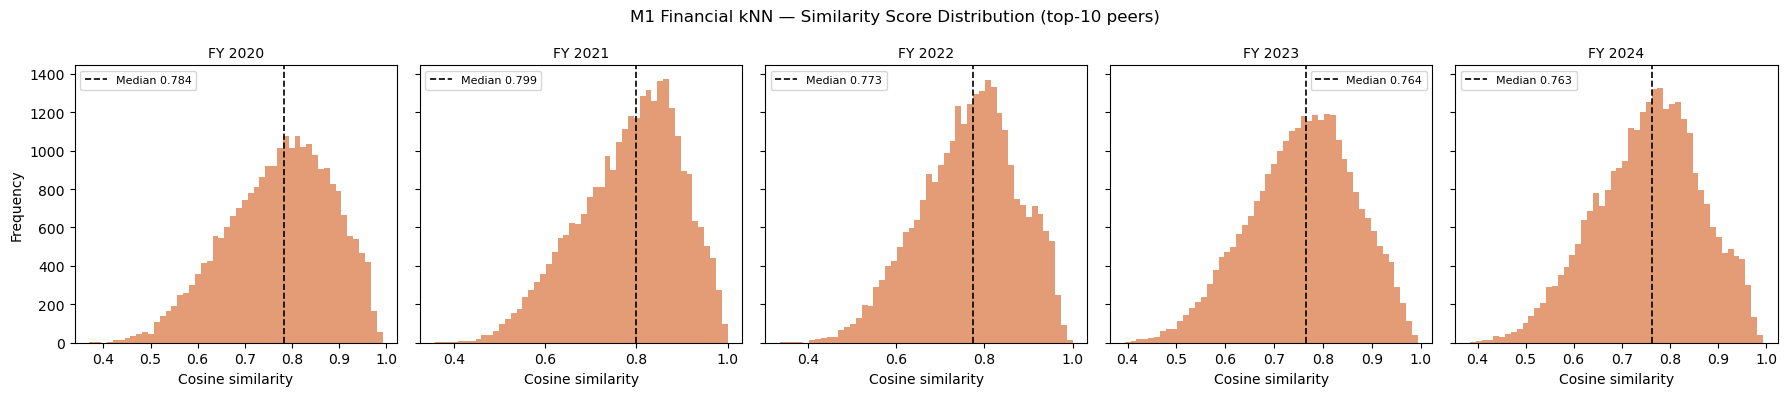

Saved: /work/Repo/figures/n6_m1_similarity_distribution.pdf


In [8]:
# Cell 8 — similarity score distribution by year
fig, axes = plt.subplots(1, len(YEARS), figsize=(18, 4), sharey=True)

for ax, yr in zip(axes, YEARS):
    data = peers_m1[(peers_m1['focal_fyear'] == yr) & 
                    (peers_m1['rank'] <= K_MAIN)]['similarity_score']
    ax.hist(data, bins=50, color='#DD8452', alpha=0.8, edgecolor='none')
    ax.axvline(data.median(), color='black', linewidth=1.2, 
               linestyle='--', label=f'Median {data.median():.3f}')
    ax.set_title(f"FY {yr}", fontsize=10)
    ax.set_xlabel("Cosine similarity")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
plt.suptitle(f"M1 Financial kNN — Similarity Score Distribution (top-{K_MAIN} peers)", 
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "n6_m1_similarity_distribution.pdf", dpi=FIGURE_DPI, 
            bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n6_m1_similarity_distribution.pdf'}")


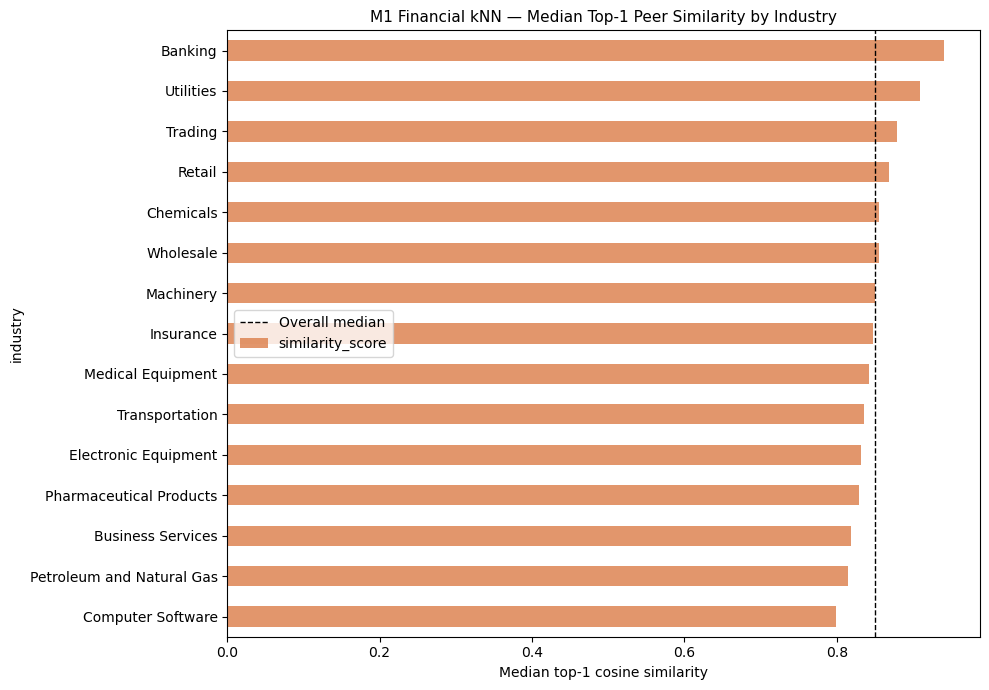

Saved: /work/Repo/figures/n6_m1_similarity_by_industry.pdf


In [9]:
# Cell 9 — top-1 similarity by FF49 industry
# Merge industry labels back from financials_norm
df_industry = df[['tic', 'fyear', 'ff49_abbr', 'industry']].copy()

peers_top1 = peers_m1[peers_m1['rank'] == 1].copy()
peers_top1 = peers_top1.merge(
    df_industry.rename(columns={'tic': 'focal_tic', 'fyear': 'focal_fyear'}),
    on=['focal_tic', 'focal_fyear'], how='left'
)

top_industries = (peers_top1.groupby('industry')['focal_tic']
                             .count()
                             .sort_values(ascending=False)
                             .head(15).index.tolist())

industry_sim = (peers_top1[peers_top1['industry'].isin(top_industries)]
                .groupby('industry')['similarity_score']
                .median()
                .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
industry_sim.plot(kind='barh', ax=ax, color='#DD8452', alpha=0.85)
ax.set_xlabel("Median top-1 cosine similarity")
ax.set_title("M1 Financial kNN — Median Top-1 Peer Similarity by Industry", fontsize=11)
ax.axvline(peers_top1['similarity_score'].median(), color='black',
           linewidth=1, linestyle='--', label='Overall median')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "n6_m1_similarity_by_industry.pdf", dpi=FIGURE_DPI,
            bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n6_m1_similarity_by_industry.pdf'}")


In [10]:
# Cell 10 — spot check: top-5 peers for 3 sample firms
print("SPOT CHECK — Top-5 M1 Financial Peers")
print("=" * 65)

# Pick one firm from tech, pharma, retail
sample_firms = []
for industry_label in ['Computer Software', 'Pharmaceutical Products', 'Retail']:
    candidates = df_industry[
        (df_industry['industry'] == industry_label) & 
        (df_industry['fyear'] == 2022)
    ]['tic'].values
    if len(candidates) > 0:
        sample_firms.append((candidates[0], 2022, industry_label))

for tic, yr, industry in sample_firms:
    top5 = (peers_m1[(peers_m1['focal_tic'] == tic) & 
                     (peers_m1['focal_fyear'] == yr) &
                     (peers_m1['rank'] <= 5)]
            .sort_values('rank')[['rank', 'peer_tic', 'similarity_score']])
    print(f"\nFocal: {tic} ({industry}, FY{yr})")
    print(top5.to_string(index=False))


SPOT CHECK — Top-5 M1 Financial Peers

Focal: ADSK (Computer Software, FY2022)
 rank peer_tic  similarity_score
    1      UNH          0.780485
    2     JAMF          0.695206
    3       IT          0.691338
    4      MAR          0.664231
    5     ZBRA          0.663458

Focal: AMGN (Pharmaceutical Products, FY2022)
 rank peer_tic  similarity_score
    1      MSI          0.937099
    2      STX          0.925491
    3       CL          0.924933
    4      MTD          0.913104
    5      HRB          0.909844

Focal: BBY (Retail, FY2022)
 rank peer_tic  similarity_score
    1      TGT          0.847047
    2       KR          0.829270
    3      TJX          0.824982
    4      WMT          0.819941
    5      MED          0.797570


## 4. FF49 Same-Industry Rate

Check what fraction of M1 top-k peers share the same FF49 industry as the focal firm.
This is a key diagnostic — if M1 finds mostly same-industry peers it is behaving
similarly to M0 (FF49 baseline). If it crosses industry lines it is adding genuine
information beyond the baseline.


In [11]:
# Cell 11 — FF49 same-industry rate for M1 vs M0 baseline
# Merge industry for both focal and peer firms
df_tic_industry = (df[['tic', 'fyear', 'ff49_num', 'industry']]
                   .drop_duplicates()
                   .copy())

# Focal industry
peers_check = peers_m1[peers_m1['rank'] <= K_MAIN].copy()
peers_check = peers_check.merge(
    df_tic_industry.rename(columns={
        'tic': 'focal_tic', 'fyear': 'focal_fyear',
        'ff49_num': 'focal_ff49', 'industry': 'focal_industry'
    }),
    on=['focal_tic', 'focal_fyear'], how='left'
)

# Peer industry (fyear = focal_fyear)
peers_check = peers_check.merge(
    df_tic_industry.rename(columns={
        'tic': 'peer_tic', 'fyear': 'focal_fyear',
        'ff49_num': 'peer_ff49', 'industry': 'peer_industry'
    }),
    on=['peer_tic', 'focal_fyear'], how='left'
)

peers_check['same_ff49'] = peers_check['focal_ff49'] == peers_check['peer_ff49']
same_rate = peers_check['same_ff49'].mean() * 100

print(f"M1 Financial kNN — FF49 same-industry rate (k={K_MAIN}):")
print(f"  {same_rate:.1f}% of top-{K_MAIN} peers share the focal firm's FF49 industry")
print(f"  {100-same_rate:.1f}% of peers cross FF49 industry boundaries")
print()
print("Same-industry rate by year:")
by_year = peers_check.groupby('focal_fyear')['same_ff49'].mean() * 100
for yr, rate in by_year.items():
    print(f"  {yr}: {rate:.1f}%")
print()
print("Interpretation:")
if same_rate > 80:
    print("  M1 closely mirrors FF49 — financial ratios strongly predict industry membership")
elif same_rate > 50:
    print("  M1 partially crosses industry lines — adds information beyond FF49")
else:
    print("  M1 frequently crosses industry lines — substantially different from M0")


M1 Financial kNN — FF49 same-industry rate (k=10):
  35.4% of top-10 peers share the focal firm's FF49 industry
  64.6% of peers cross FF49 industry boundaries

Same-industry rate by year:
  2020: 35.8%
  2021: 34.2%
  2022: 36.1%
  2023: 35.9%
  2024: 35.2%

Interpretation:
  M1 frequently crosses industry lines — substantially different from M0


## 5. Save

In [12]:
# Cell 12 — save peers_m1.parquet
PEERS_M1.parent.mkdir(parents=True, exist_ok=True)
peers_m1.to_parquet(PEERS_M1, index=False)

print(f"Saved : {PEERS_M1}")
print(f"Shape : {peers_m1.shape[0]:,} rows × {peers_m1.shape[1]} columns")
print()
print("Peer records per year:")
print(peers_m1.groupby('focal_fyear')['focal_tic'].count().to_string())
print()
print(f"Unique focal firms: {peers_m1['focal_tic'].nunique():,}")
print(f"Unique peer firms : {peers_m1['peer_tic'].nunique():,}")


Saved : /work/Repo/data/results/peers_m1.parquet
Shape : 271,180 rows × 6 columns

Peer records per year:
focal_fyear
2020    48920
2021    55620
2022    54340
2023    54840
2024    57460

Unique focal firms: 3,494
Unique peer firms : 3,493


In [13]:
# Cell 13 — final summary
print("=" * 60)
print("N6 COMPLETE — M1 FINANCIAL KNN SUMMARY")
print("=" * 60)
print(f"  Model          : M1_Financial")
print(f"  Method         : Cosine kNN")
print(f"  Feature space  : {len(selected_features)}-dim normalised financial ratios")
print(f"  k retrieved    : up to {max(K_ROBUSTNESS)} (filter to k in N9)")
print(f"  Years          : {YEARS}")
print(f"  Total records  : {len(peers_m1):,}")
print()
print(f"  Output: {PEERS_M1}")
print()
print("  Next steps:")
print("  → N7: kNN text (M2) — requires N5 embeddings first")
print("  → N9: can already compute M0 baseline + partial M1 results")


N6 COMPLETE — M1 FINANCIAL KNN SUMMARY
  Model          : M1_Financial
  Method         : Cosine kNN
  Feature space  : 64-dim normalised financial ratios
  k retrieved    : up to 20 (filter to k in N9)
  Years          : [2020, 2021, 2022, 2023, 2024]
  Total records  : 271,180

  Output: /work/Repo/data/results/peers_m1.parquet

  Next steps:
  → N7: kNN text (M2) — requires N5 embeddings first
  → N9: can already compute M0 baseline + partial M1 results
